# Iris 품종 분류 - 머신러닝 기초 예제

이 노트북은 머신러닝의 대표적인 입문 데이터셋인 Iris 품종 분류 문제를 다룹니다.

**목표**: 꽃잎과 꽃받침의 길이/폭 정보를 바탕으로 붓꽃의 품종을 분류하는 다중 클래스 분류 문제

## 1. 라이브러리 임포트 및 설정

In [1]:
# 데이터 처리 라이브러리
import pandas as pd
import numpy as np

# 시각화 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# 머신러닝 라이브러리
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support, roc_curve, auc
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# 경고 메시지 제거
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Mac의 경우)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 시드 설정
np.random.seed(42)

# 출력 옵션 설정
pd.set_option('display.max_columns', None)
np.set_printoptions(precision=3)

## 2. 데이터 로드 및 기본 정보 확인

In [2]:
# Iris 데이터셋 로드
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# 데이터프레임 생성
df = pd.DataFrame(X, columns=feature_names)
df['species'] = pd.Categorical.from_codes(y, target_names)
df['target'] = y

print("=== Iris 데이터셋 정보 ===")
print(f"데이터셋 크기: {df.shape}")
print(f"특성 개수: {len(feature_names)}")
print(f"클래스 개수: {len(target_names)}")
print(f"클래스 이름: {list(target_names)}")

print("\n=== 특성 정보 ===")
for i, name in enumerate(feature_names):
    print(f"{i+1}. {name}")

print("\n=== 첫 5행 ===")
df.head()

=== Iris 데이터셋 정보 ===
데이터셋 크기: (150, 6)
특성 개수: 4
클래스 개수: 3
클래스 이름: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

=== 특성 정보 ===
1. sepal length (cm)
2. sepal width (cm)
3. petal length (cm)
4. petal width (cm)

=== 첫 5행 ===


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,target
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,0


In [3]:
# 데이터 기본 정보
print("=== 데이터 기본 정보 ===")
df.info()

print("\n=== 기술 통계 ===")
print(df.describe())

print("\n=== 클래스별 분포 ===")
print(df['species'].value_counts())
print(f"\n클래스 균형도: {df['species'].value_counts().std():.2f} (낮을수록 균형적)")

print("\n=== 결측값 확인 ===")
missing_values = df.isnull().sum()
print(f"총 결측값: {missing_values.sum()}개")
if missing_values.sum() > 0:
    print(missing_values[missing_values > 0])
else:
    print("결측값이 없습니다.")

=== 데이터 기본 정보 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
 5   target             150 non-null    int64   
dtypes: category(1), float64(4), int64(1)
memory usage: 6.3 KB

=== 기술 통계 ===
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.

## 3. 탐색적 데이터 분석 (EDA)

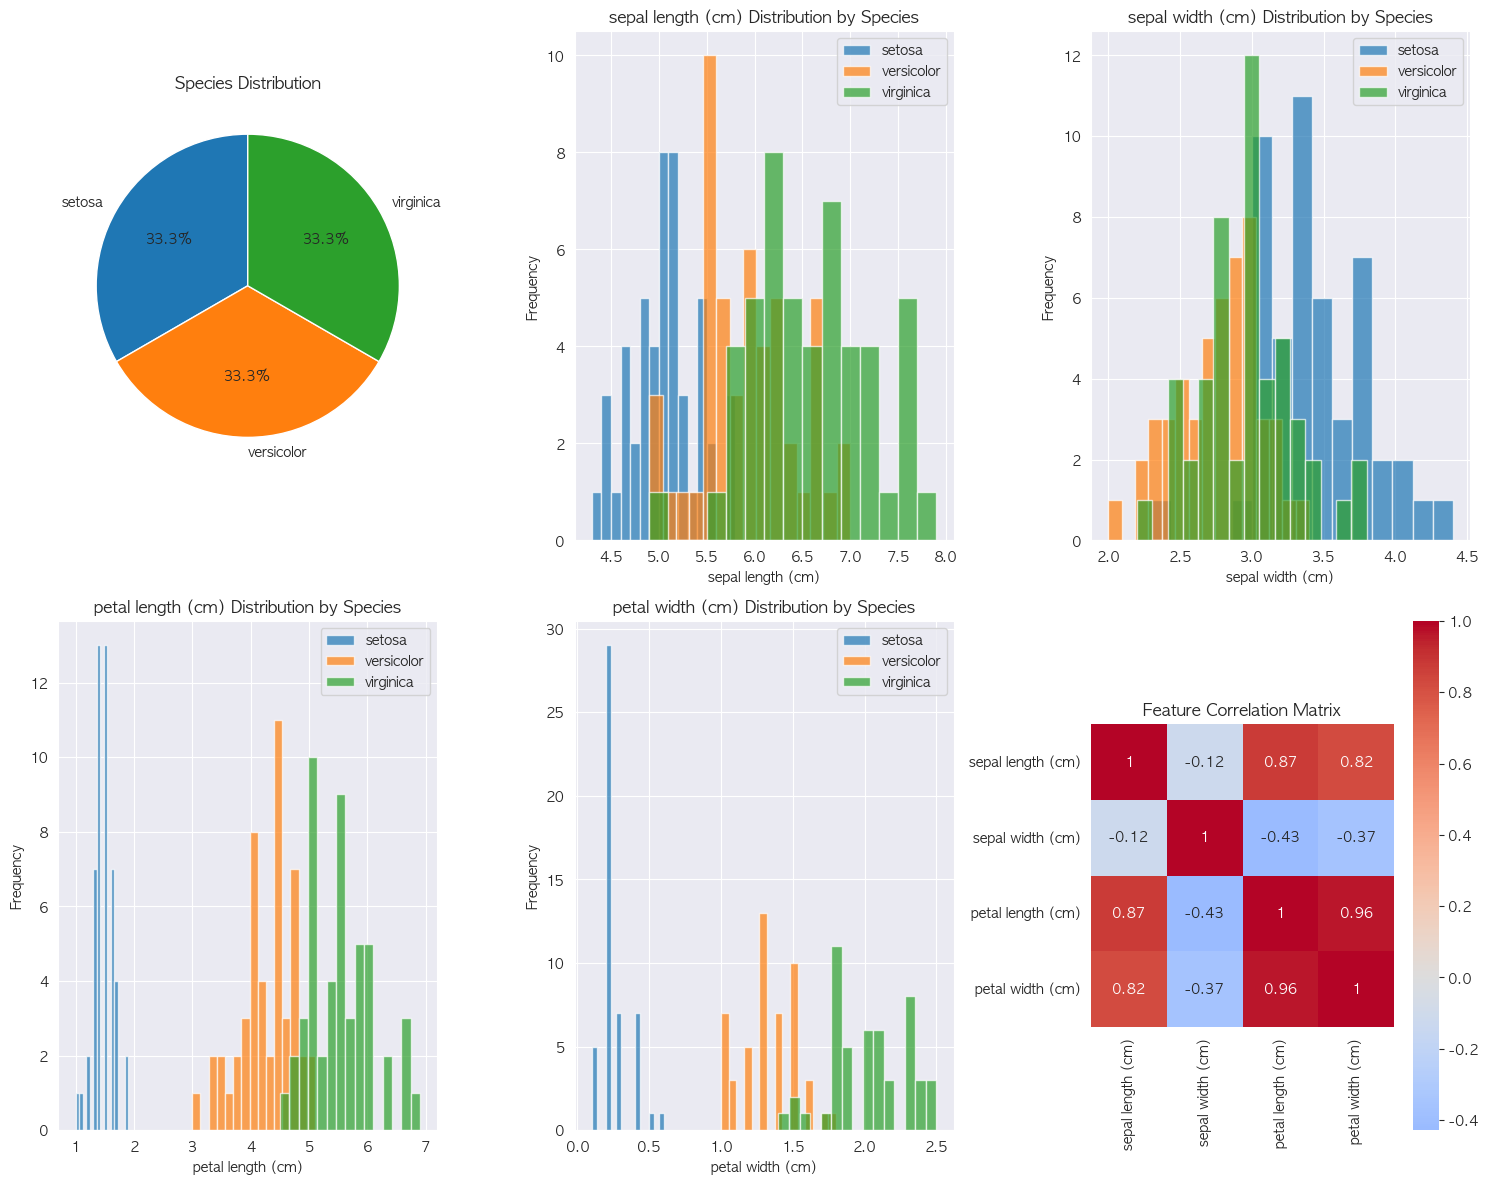

=== 특성 간 상관관계 ===
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


In [4]:
# 기본 시각화
plt.figure(figsize=(15, 12))

# 클래스별 분포
plt.subplot(2, 3, 1)
species_counts = df['species'].value_counts()
plt.pie(species_counts.values, labels=species_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Species Distribution')

# 특성별 히스토그램
for i, feature in enumerate(feature_names):
    plt.subplot(2, 3, i+2)
    for species in target_names:
        data = df[df['species'] == species][feature]
        plt.hist(data, alpha=0.7, label=species, bins=15)
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.title(f'{feature} Distribution by Species')
    plt.legend()

# 상관관계 히트맵
plt.subplot(2, 3, 6)
correlation_matrix = df[feature_names].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Matrix')

plt.tight_layout()
plt.show()

print("=== 특성 간 상관관계 ===")
print(correlation_matrix)

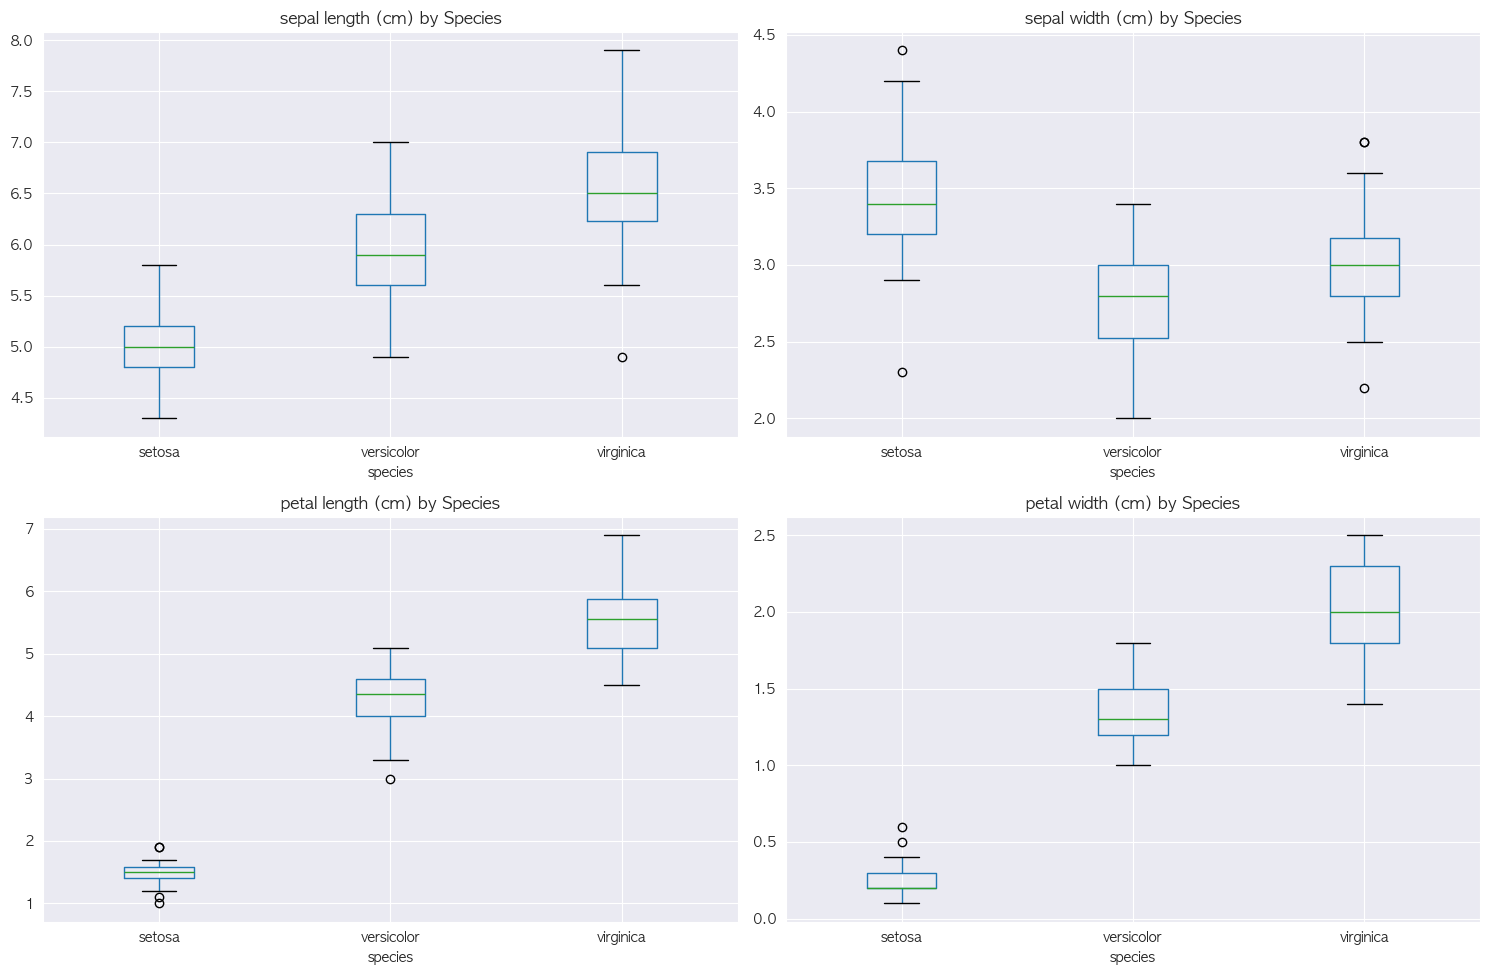

<Figure size 1200x1000 with 0 Axes>

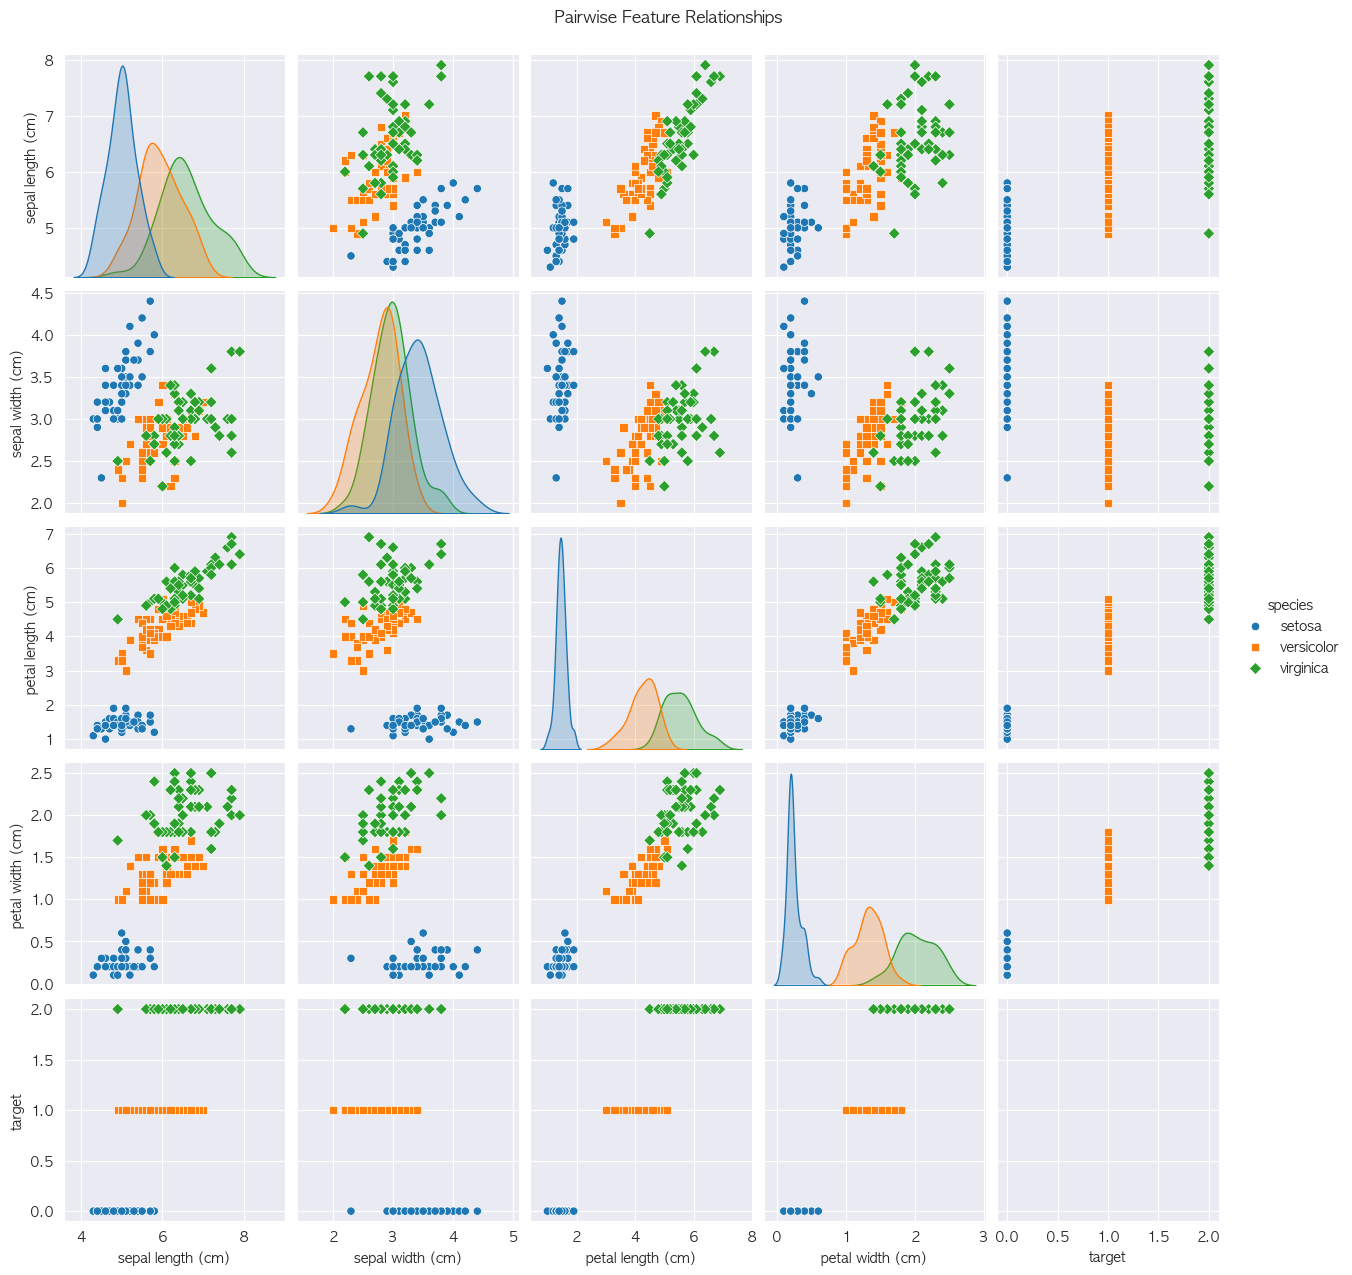

In [5]:
# 고급 시각화 - 페어플롯과 박스플롯
plt.figure(figsize=(15, 10))

# 박스플롯 - 특성별 분포
for i, feature in enumerate(feature_names):
    plt.subplot(2, 2, i+1)
    df.boxplot(column=feature, by='species', ax=plt.gca())
    plt.title(f'{feature} by Species')
    plt.suptitle('')  # 제목 중복 제거

plt.tight_layout()
plt.show()

# 페어플롯 (seaborn)
plt.figure(figsize=(12, 10))
sns.pairplot(df, hue='species', markers=['o', 's', 'D'])
plt.suptitle('Pairwise Feature Relationships', y=1.02)
plt.show()

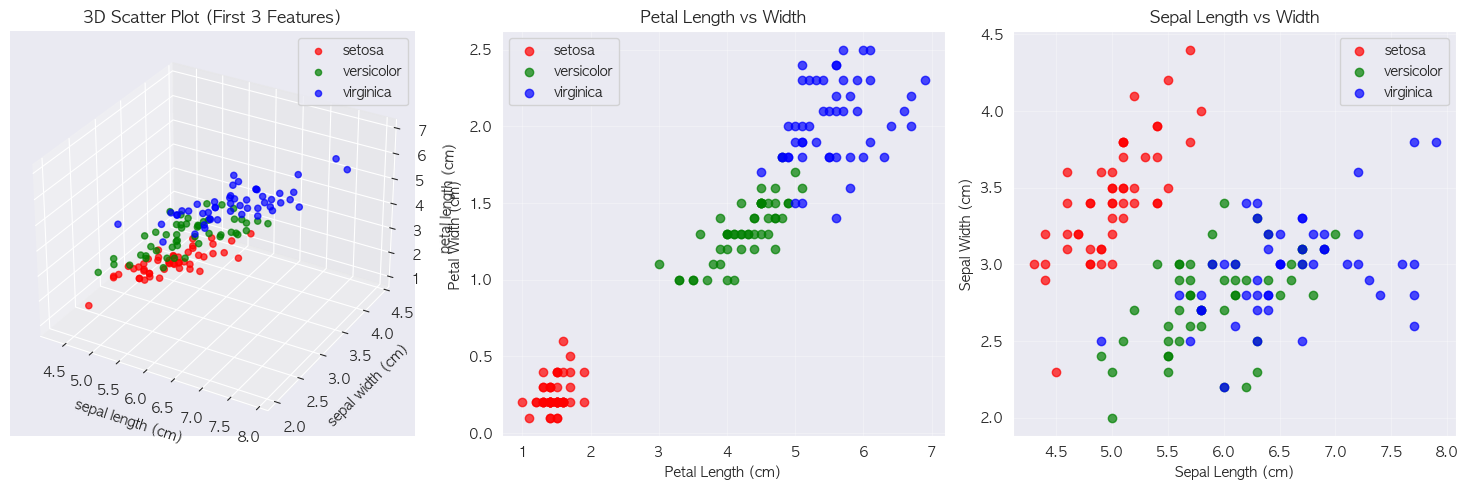

In [6]:
# 3D 시각화 (처음 3개 특성 사용)
fig = plt.figure(figsize=(15, 5))

# 3D 산점도 (sepal length, sepal width, petal length)
ax1 = fig.add_subplot(131, projection='3d')
colors = ['red', 'green', 'blue']
for i, species in enumerate(target_names):
    species_data = df[df['species'] == species]
    ax1.scatter(species_data[feature_names[0]], 
               species_data[feature_names[1]], 
               species_data[feature_names[2]], 
               c=colors[i], label=species, alpha=0.7)
ax1.set_xlabel(feature_names[0])
ax1.set_ylabel(feature_names[1])
ax1.set_zlabel(feature_names[2])
ax1.set_title('3D Scatter Plot (First 3 Features)')
ax1.legend()

# 2D 산점도 - petal length vs petal width
ax2 = fig.add_subplot(132)
for i, species in enumerate(target_names):
    species_data = df[df['species'] == species]
    ax2.scatter(species_data['petal length (cm)'], 
               species_data['petal width (cm)'], 
               c=colors[i], label=species, alpha=0.7)
ax2.set_xlabel('Petal Length (cm)')
ax2.set_ylabel('Petal Width (cm)')
ax2.set_title('Petal Length vs Width')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 2D 산점도 - sepal length vs sepal width
ax3 = fig.add_subplot(133)
for i, species in enumerate(target_names):
    species_data = df[df['species'] == species]
    ax3.scatter(species_data['sepal length (cm)'], 
               species_data['sepal width (cm)'], 
               c=colors[i], label=species, alpha=0.7)
ax3.set_xlabel('Sepal Length (cm)')
ax3.set_ylabel('Sepal Width (cm)')
ax3.set_title('Sepal Length vs Width')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# 통계적 분석
print("=== 클래스별 특성 통계 ===")
for species in target_names:
    print(f"\n{species.upper()}:")
    species_data = df[df['species'] == species][feature_names]
    print(species_data.describe())

# 클래스 간 평균 차이 분석
print("\n=== 클래스별 평균값 ===")
class_means = df.groupby('species')[feature_names].mean()
print(class_means)

print("\n=== 특성별 클래스 간 분산 ===")
for feature in feature_names:
    variance_between = df.groupby('species')[feature].var()
    print(f"{feature}:")
    print(f"  클래스 간 분산: {variance_between}")
    print(f"  평균 분산: {variance_between.mean():.3f}")

=== 클래스별 특성 통계 ===

SETOSA:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count           50.00000         50.000000          50.000000   
mean             5.00600          3.428000           1.462000   
std              0.35249          0.379064           0.173664   
min              4.30000          2.300000           1.000000   
25%              4.80000          3.200000           1.400000   
50%              5.00000          3.400000           1.500000   
75%              5.20000          3.675000           1.575000   
max              5.80000          4.400000           1.900000   

       petal width (cm)  
count         50.000000  
mean           0.246000  
std            0.105386  
min            0.100000  
25%            0.200000  
50%            0.200000  
75%            0.300000  
max            0.600000  

VERSICOLOR:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count          50.000000         50.000000          50.000000   
mean     

## 4. 데이터 전처리 및 차원 축소

In [8]:
# 데이터 분할
print("=== 데이터 분할 ===")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"전체 데이터: {X.shape}")
print(f"훈련 데이터: {X_train.shape}")
print(f"테스트 데이터: {X_test.shape}")

# 클래스별 분포 확인
train_distribution = pd.Series(y_train).value_counts().sort_index()
test_distribution = pd.Series(y_test).value_counts().sort_index()

print("\n=== 분할 후 클래스 분포 ===")
print("훈련 데이터:", train_distribution.values)
print("테스트 데이터:", test_distribution.values)

# 특성 스케일링
print("\n=== 특성 스케일링 ===")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("스케일링 전 통계:")
print(f"  평균: {X_train.mean(axis=0)}")
print(f"  표준편차: {X_train.std(axis=0)}")

print("스케일링 후 통계:")
print(f"  평균: {X_train_scaled.mean(axis=0)}")
print(f"  표준편차: {X_train_scaled.std(axis=0)}")

=== 데이터 분할 ===
전체 데이터: (150, 4)
훈련 데이터: (105, 4)
테스트 데이터: (45, 4)

=== 분할 후 클래스 분포 ===
훈련 데이터: [35 35 35]
테스트 데이터: [15 15 15]

=== 특성 스케일링 ===
스케일링 전 통계:
  평균: [5.87333333 3.0552381  3.7847619  1.20571429]
  표준편차: [0.85882164 0.45502087 1.77553646 0.77383751]
스케일링 후 통계:
  평균: [ 2.38327876e-15 -1.12145742e-15 -1.37456184e-16 -6.97854473e-17]
  표준편차: [1. 1. 1. 1.]


=== 차원 축소 분석 ===
PCA 설명 분산 비율: [0.7264421  0.23378786 0.03518741 0.00458263]
PCA 누적 설명 분산 비율: [0.7264421  0.96022997 0.99541737 1.        ]
첫 2개 주성분으로 설명되는 분산: 96.0%


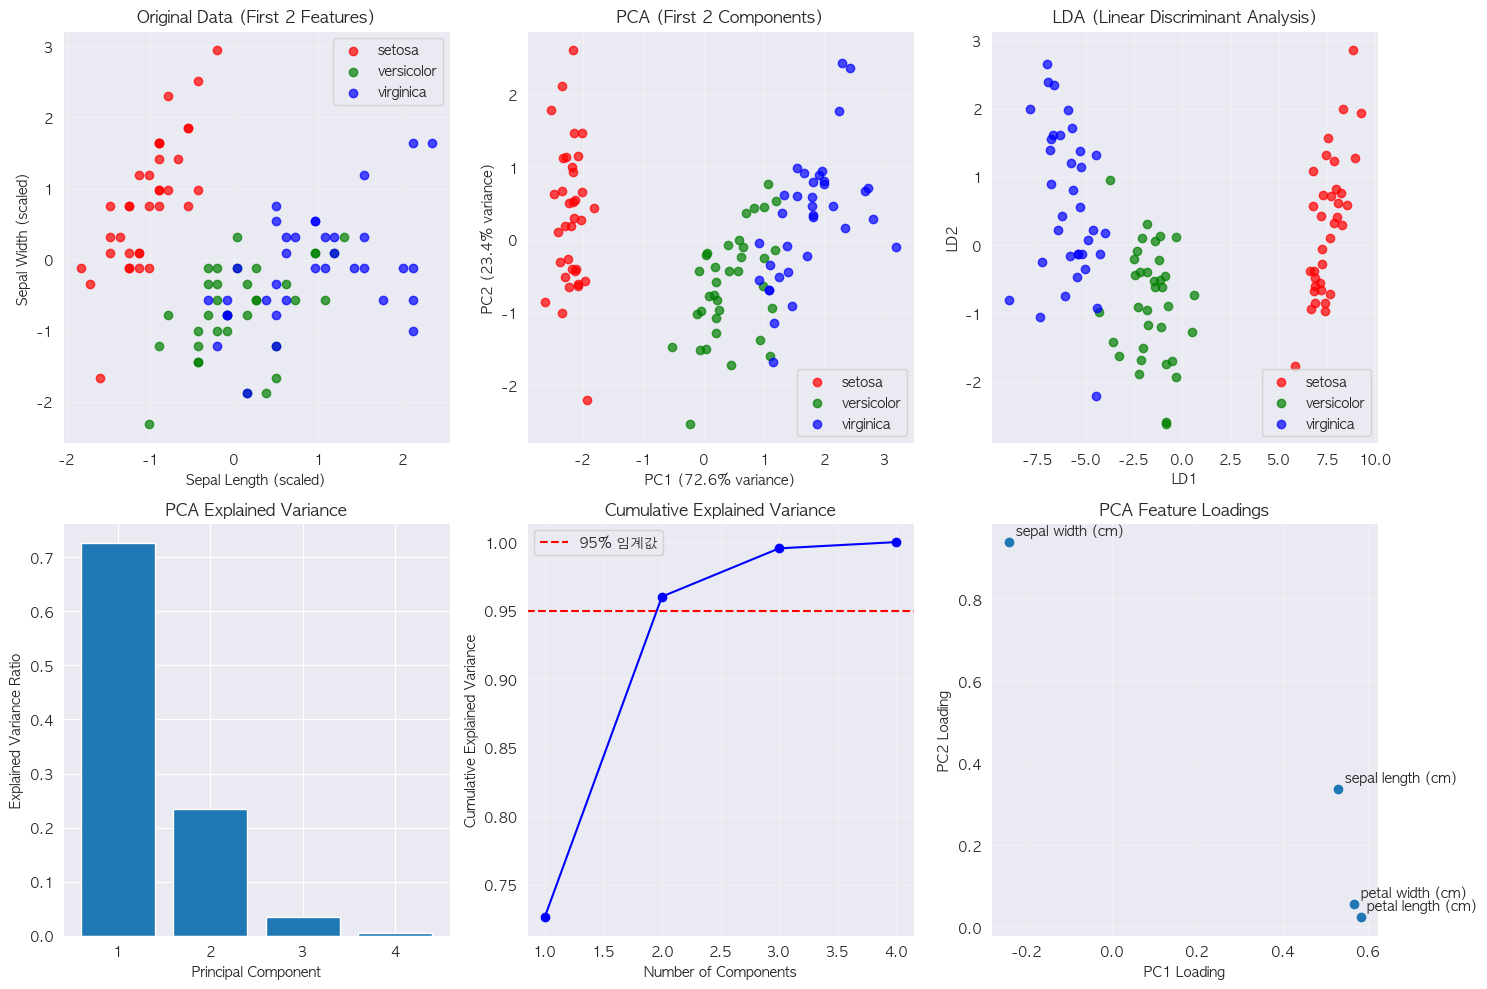

In [9]:
# 차원 축소 - PCA와 LDA
print("=== 차원 축소 분석 ===")

# PCA (주성분 분석)
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# LDA (선형판별분석)
lda = LinearDiscriminantAnalysis()
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)

print("PCA 설명 분산 비율:", pca.explained_variance_ratio_)
print("PCA 누적 설명 분산 비율:", np.cumsum(pca.explained_variance_ratio_))
print(f"첫 2개 주성분으로 설명되는 분산: {np.sum(pca.explained_variance_ratio_[:2]):.1%}")

# 시각화
plt.figure(figsize=(15, 10))

# 원본 데이터 (첫 2개 특성)
plt.subplot(2, 3, 1)
colors = ['red', 'green', 'blue']
for i, species in enumerate(target_names):
    mask = y_train == i
    plt.scatter(X_train_scaled[mask, 0], X_train_scaled[mask, 1], 
               c=colors[i], label=species, alpha=0.7)
plt.xlabel('Sepal Length (scaled)')
plt.ylabel('Sepal Width (scaled)')
plt.title('Original Data (First 2 Features)')
plt.legend()
plt.grid(True, alpha=0.3)

# PCA 결과 (첫 2개 주성분)
plt.subplot(2, 3, 2)
for i, species in enumerate(target_names):
    mask = y_train == i
    plt.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1], 
               c=colors[i], label=species, alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA (First 2 Components)')
plt.legend()
plt.grid(True, alpha=0.3)

# LDA 결과
plt.subplot(2, 3, 3)
for i, species in enumerate(target_names):
    mask = y_train == i
    plt.scatter(X_train_lda[mask, 0], X_train_lda[mask, 1], 
               c=colors[i], label=species, alpha=0.7)
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.title('LDA (Linear Discriminant Analysis)')
plt.legend()
plt.grid(True, alpha=0.3)

# PCA 성분 기여도
plt.subplot(2, 3, 4)
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance')
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))

# 누적 설명 분산
plt.subplot(2, 3, 5)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         np.cumsum(pca.explained_variance_ratio_), 'bo-')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% 임계값')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)

# PCA 로딩 (특성 기여도)
plt.subplot(2, 3, 6)
loadings = pca.components_[:2].T
plt.scatter(loadings[:, 0], loadings[:, 1])
for i, feature in enumerate(feature_names):
    plt.annotate(feature, (loadings[i, 0], loadings[i, 1]), 
                xytext=(5, 5), textcoords='offset points')
plt.xlabel('PC1 Loading')
plt.ylabel('PC2 Loading')
plt.title('PCA Feature Loadings')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. 다양한 분류 모델 학습 및 비교

In [10]:
# 다양한 분류 모델 정의
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=3),
    'Support Vector Machine': SVC(random_state=42, probability=True),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Naive Bayes': GaussianNB()
}

# 모델별 성능 저장
model_results = {}
trained_models = {}

print("=== 모델 학습 및 교차 검증 ===")

for name, model in models.items():
    print(f"\n{name} 학습 중...")
    
    # 교차 검증
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    
    # 모델 학습
    model.fit(X_train_scaled, y_train)
    
    # 예측
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # 정확도 계산
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    # 결과 저장
    model_results[name] = {
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'y_pred': y_test_pred
    }
    trained_models[name] = model
    
    print(f"  교차 검증 정확도: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print(f"  훈련 정확도: {train_accuracy:.4f}")
    print(f"  테스트 정확도: {test_accuracy:.4f}")
    
    # 과적합 여부 체크
    if train_accuracy - test_accuracy > 0.05:
        print(f"  ⚠️ 과적합 가능성 (훈련-테스트 차이: {train_accuracy - test_accuracy:.3f})")

# 최고 성능 모델 찾기
best_model_name = max(model_results.keys(), key=lambda x: model_results[x]['test_accuracy'])
print(f"\n🏆 최고 성능 모델: {best_model_name} (정확도: {model_results[best_model_name]['test_accuracy']:.4f})")

=== 모델 학습 및 교차 검증 ===

Logistic Regression 학습 중...
  교차 검증 정확도: 0.9810 (+/- 0.0467)
  훈련 정확도: 0.9810
  테스트 정확도: 0.9111
  ⚠️ 과적합 가능성 (훈련-테스트 차이: 0.070)

K-Nearest Neighbors 학습 중...
  교차 검증 정확도: 0.9524 (+/- 0.0852)
  훈련 정확도: 0.9714
  테스트 정확도: 0.9111
  ⚠️ 과적합 가능성 (훈련-테스트 차이: 0.060)

Support Vector Machine 학습 중...
  교차 검증 정확도: 0.9714 (+/- 0.0467)
  훈련 정확도: 0.9714
  테스트 정확도: 0.9333

Decision Tree 학습 중...
  교차 검증 정확도: 0.9429 (+/- 0.0381)
  훈련 정확도: 1.0000
  테스트 정확도: 0.9111
  ⚠️ 과적합 가능성 (훈련-테스트 차이: 0.089)

Random Forest 학습 중...
  교차 검증 정확도: 0.9524 (+/- 0.0602)
  훈련 정확도: 1.0000
  테스트 정확도: 0.8889
  ⚠️ 과적합 가능성 (훈련-테스트 차이: 0.111)

Naive Bayes 학습 중...
  교차 검증 정확도: 0.9810 (+/- 0.0467)
  훈련 정확도: 0.9810
  테스트 정확도: 0.9111
  ⚠️ 과적합 가능성 (훈련-테스트 차이: 0.070)

🏆 최고 성능 모델: Support Vector Machine (정확도: 0.9333)


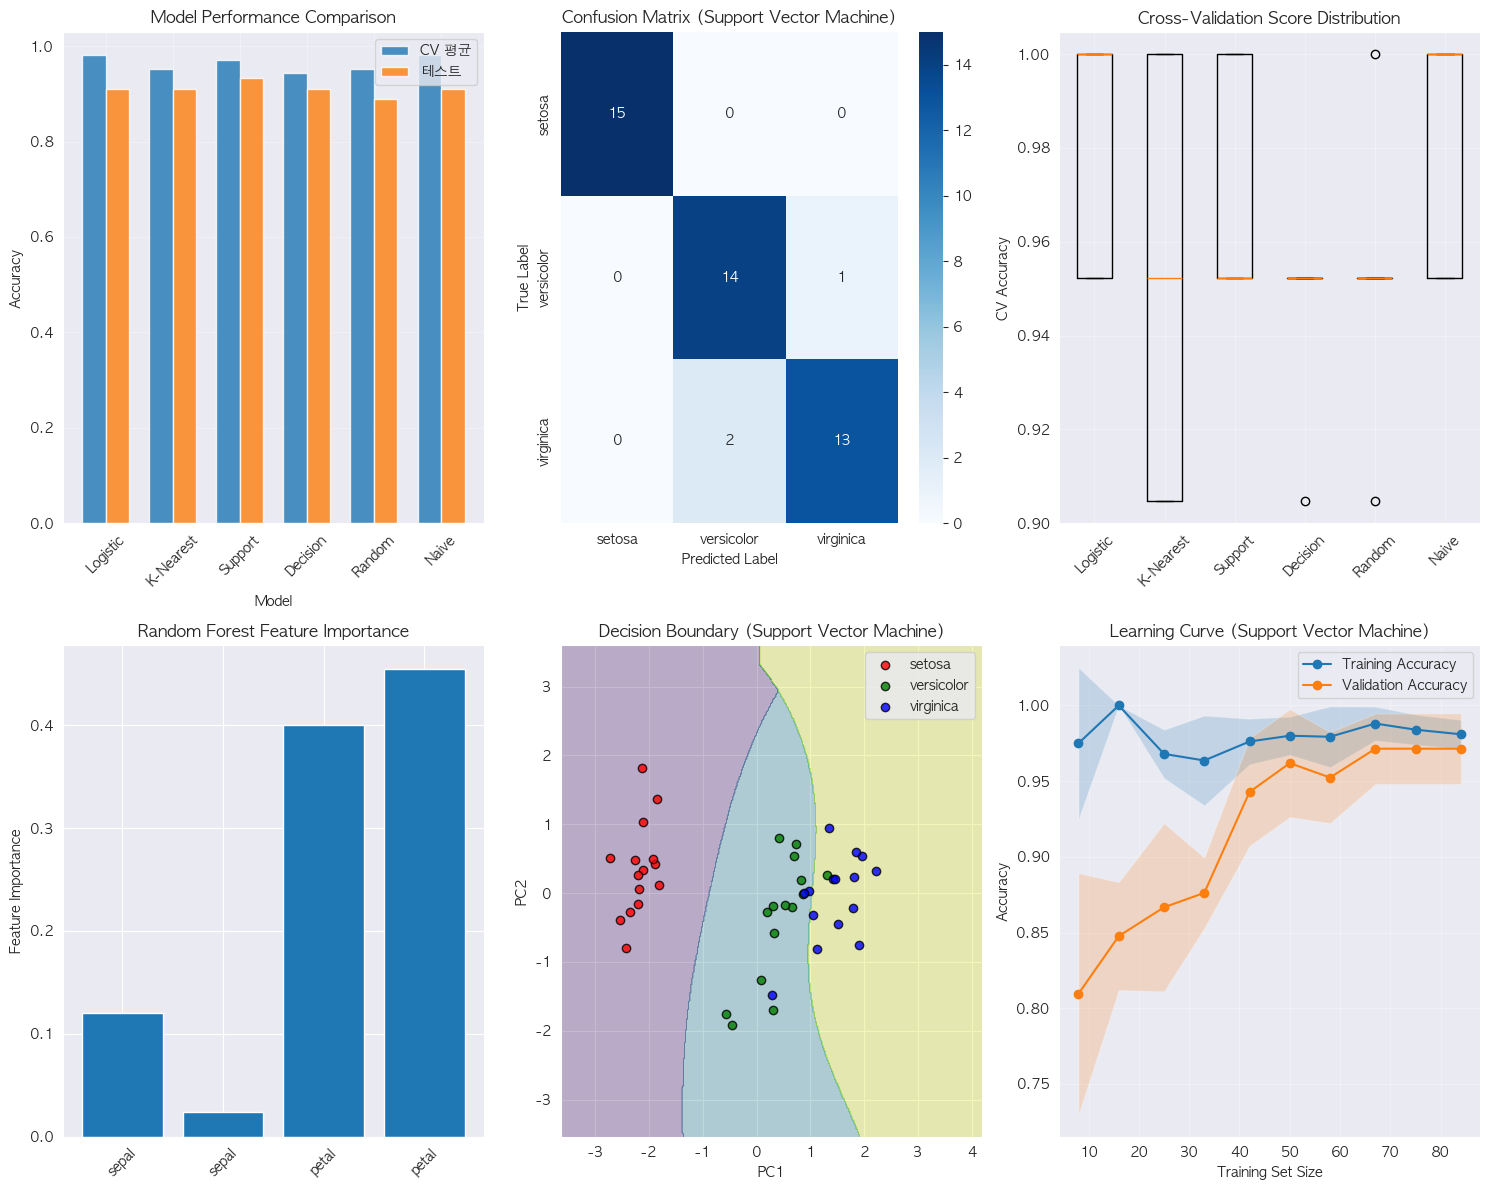

In [11]:
# 모델 성능 비교 시각화
plt.figure(figsize=(15, 12))

# 모델별 정확도 비교
plt.subplot(2, 3, 1)
model_names = list(model_results.keys())
cv_accuracies = [model_results[name]['cv_mean'] for name in model_names]
test_accuracies = [model_results[name]['test_accuracy'] for name in model_names]

x = np.arange(len(model_names))
width = 0.35

plt.bar(x - width/2, cv_accuracies, width, label='CV 평균', alpha=0.8)
plt.bar(x + width/2, test_accuracies, width, label='테스트', alpha=0.8)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.xticks(x, [name.split()[0] for name in model_names], rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

# 최고 모델의 혼동 행렬
plt.subplot(2, 3, 2)
best_predictions = model_results[best_model_name]['y_pred']
cm = confusion_matrix(y_test, best_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title(f'Confusion Matrix ({best_model_name})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# 모델별 CV 점수 분포 (박스플롯)
plt.subplot(2, 3, 3)
cv_scores_all = []
labels = []
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    cv_scores_all.append(scores)
    labels.append(name.split()[0])

plt.boxplot(cv_scores_all, labels=labels)
plt.ylabel('CV Accuracy')
plt.title('Cross-Validation Score Distribution')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# 특성 중요도 (Random Forest)
if 'Random Forest' in trained_models:
    plt.subplot(2, 3, 4)
    rf_model = trained_models['Random Forest']
    feature_importance = rf_model.feature_importances_
    
    plt.bar(range(len(feature_importance)), feature_importance)
    plt.xticks(range(len(feature_importance)), 
              [name.split()[0] for name in feature_names], rotation=45)
    plt.ylabel('Feature Importance')
    plt.title('Random Forest Feature Importance')

# 결정 경계 시각화 (PCA 공간에서)
plt.subplot(2, 3, 5)
best_model = trained_models[best_model_name]

# PCA로 2차원으로 축소된 데이터로 모델 재학습
X_train_2d = X_train_pca[:, :2]
X_test_2d = X_test_pca[:, :2]

# 동일한 타입의 모델로 2D 데이터에서 학습
model_2d = type(best_model)(random_state=42) if hasattr(type(best_model), 'random_state') else type(best_model)()
if hasattr(model_2d, 'probability'):
    model_2d.probability = True
if hasattr(model_2d, 'max_iter'):
    model_2d.max_iter = 1000
    
model_2d.fit(X_train_2d, y_train)

# 결정 경계 그리기
h = 0.02
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                    np.arange(y_min, y_max, h))

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
colors = ['red', 'green', 'blue']
for i, species in enumerate(target_names):
    mask = y_test == i
    plt.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1], 
               c=colors[i], label=species, alpha=0.8, edgecolors='black')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'Decision Boundary ({best_model_name})')
plt.legend()

# 학습 곡선
plt.subplot(2, 3, 6)
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_scaled, y_train, 
    train_sizes=np.linspace(0.1, 1.0, 10), cv=5
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.plot(train_sizes, train_mean, 'o-', label='Training Accuracy')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.plot(train_sizes, val_mean, 'o-', label='Validation Accuracy')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title(f'Learning Curve ({best_model_name})')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. 하이퍼파라미터 튜닝

In [12]:
# 최고 성능 모델에 대한 하이퍼파라미터 튜닝
print(f"=== {best_model_name} 하이퍼파라미터 튜닝 ===")

# 모델별 파라미터 그리드 정의
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'lbfgs']
    },
    'K-Nearest Neighbors': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'Support Vector Machine': {
        'C': [0.1, 1, 10, 100],
        'kernel': ['linear', 'rbf', 'poly'],
        'gamma': ['scale', 'auto', 0.01, 0.1, 1]
    },
    'Decision Tree': {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7, None],
        'min_samples_split': [2, 5, 10]
    },
    'Naive Bayes': {
        'var_smoothing': [1e-10, 1e-9, 1e-8, 1e-7, 1e-6]
    }
}

if best_model_name in param_grids:
    # 기본 모델 타입 가져오기
    base_model = type(trained_models[best_model_name])()
    if hasattr(base_model, 'random_state'):
        base_model.random_state = 42
    if hasattr(base_model, 'probability'):
        base_model.probability = True
    if hasattr(base_model, 'max_iter'):
        base_model.max_iter = 1000
    
    # 그리드 서치 실행
    param_grid = param_grids[best_model_name]
    grid_search = GridSearchCV(
        base_model, param_grid, 
        cv=5, scoring='accuracy', 
        n_jobs=-1, verbose=1
    )
    
    grid_search.fit(X_train_scaled, y_train)
    
    print(f"최적 파라미터: {grid_search.best_params_}")
    print(f"최적 교차 검증 점수: {grid_search.best_score_:.4f}")
    
    # 최적화된 모델로 예측
    best_tuned_model = grid_search.best_estimator_
    y_pred_tuned = best_tuned_model.predict(X_test_scaled)
    tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
    
    print(f"\n성능 비교:")
    print(f"튜닝 전 테스트 정확도: {model_results[best_model_name]['test_accuracy']:.4f}")
    print(f"튜닝 후 테스트 정확도: {tuned_accuracy:.4f}")
    print(f"개선도: {tuned_accuracy - model_results[best_model_name]['test_accuracy']:.4f}")
    
    # 상위 파라미터 조합들 확인
    print("\n상위 5개 파라미터 조합:")
    results_df = pd.DataFrame(grid_search.cv_results_)
    top_results = results_df.nlargest(5, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']]
    for idx, row in top_results.iterrows():
        print(f"  {row['mean_test_score']:.4f} (+/- {row['std_test_score']*2:.4f}): {row['params']}")
        
else:
    print(f"{best_model_name}에 대한 파라미터 그리드가 정의되지 않았습니다.")

=== Support Vector Machine 하이퍼파라미터 튜닝 ===
Fitting 5 folds for each of 60 candidates, totalling 300 fits
최적 파라미터: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
최적 교차 검증 점수: 0.9810

성능 비교:
튜닝 전 테스트 정확도: 0.9333
튜닝 후 테스트 정확도: 0.9111
개선도: -0.0222

상위 5개 파라미터 조합:
  0.9810 (+/- 0.0467): {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
  0.9810 (+/- 0.0467): {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
  0.9810 (+/- 0.0467): {'C': 100, 'gamma': 'auto', 'kernel': 'linear'}
  0.9810 (+/- 0.0467): {'C': 100, 'gamma': 0.01, 'kernel': 'linear'}
  0.9810 (+/- 0.0467): {'C': 100, 'gamma': 0.1, 'kernel': 'linear'}


## 7. 상세한 성능 분석

In [13]:
# 상세한 분류 보고서
print("=== 상세한 분류 성능 분석 ===")

best_predictions = model_results[best_model_name]['y_pred']

# 분류 보고서
print(f"\n{best_model_name} 분류 보고서:")
print(classification_report(y_test, best_predictions, target_names=target_names))

# 클래스별 정밀도, 재현율, F1-점수
precision, recall, f1, support = precision_recall_fscore_support(y_test, best_predictions)

print("\n클래스별 상세 지표:")
for i, species in enumerate(target_names):
    print(f"{species:12}: 정밀도={precision[i]:.3f}, 재현율={recall[i]:.3f}, F1={f1[i]:.3f}, 지지도={support[i]}")

# 혼동 행렬 상세 분석
cm = confusion_matrix(y_test, best_predictions)
print("\n혼동 행렬:")
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)
print(cm_df)

# 잘못 분류된 케이스 분석
misclassified = X_test_scaled[y_test != best_predictions]
misclassified_true = y_test[y_test != best_predictions]
misclassified_pred = best_predictions[y_test != best_predictions]

print(f"\n잘못 분류된 케이스: {len(misclassified)}개")
if len(misclassified) > 0:
    print("잘못 분류된 케이스들:")
    for i in range(len(misclassified)):
        true_label = target_names[misclassified_true[i]]
        pred_label = target_names[misclassified_pred[i]]
        print(f"  실제: {true_label} → 예측: {pred_label}")
        print(f"    특성값: {misclassified[i]}")

=== 상세한 분류 성능 분석 ===

Support Vector Machine 분류 보고서:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45


클래스별 상세 지표:
setosa      : 정밀도=1.000, 재현율=1.000, F1=1.000, 지지도=15
versicolor  : 정밀도=0.875, 재현율=0.933, F1=0.903, 지지도=15
virginica   : 정밀도=0.929, 재현율=0.867, F1=0.897, 지지도=15

혼동 행렬:
            setosa  versicolor  virginica
setosa          15           0          0
versicolor       0          14          1
virginica        0           2         13

잘못 분류된 케이스: 3개
잘못 분류된 케이스들:
  실제: virginica → 예측: versicolor
    특성값: [ 0.49680475 -0.56093712  0.74075533  0.38029394]
  실제: versicolor → 예측: virginica
    특성값: [ 0.9625592  -0.12139684  0.68443432  0.63874613]
  실제:

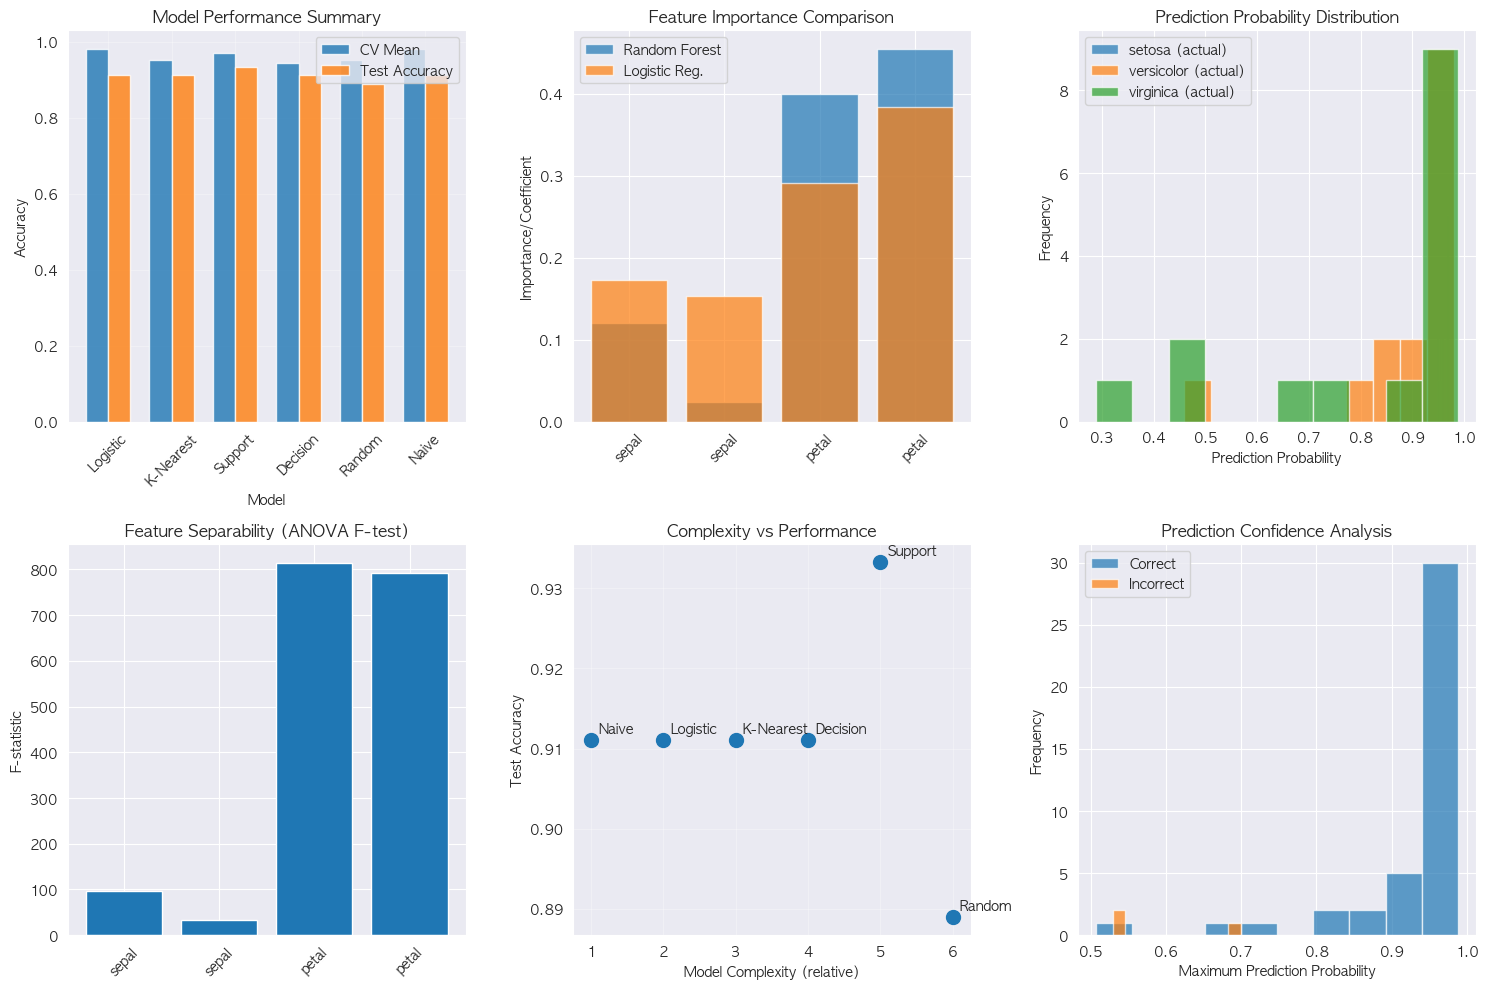

In [14]:
# 모델 해석 및 특성 중요도 분석
plt.figure(figsize=(15, 10))

# 모든 모델의 성능 메트릭 비교
plt.subplot(2, 3, 1)
metrics_comparison = pd.DataFrame({
    'Model': model_names,
    'CV_Mean': [model_results[name]['cv_mean'] for name in model_names],
    'Test_Accuracy': [model_results[name]['test_accuracy'] for name in model_names]
})

x = np.arange(len(model_names))
width = 0.35
plt.bar(x - width/2, metrics_comparison['CV_Mean'], width, label='CV Mean', alpha=0.8)
plt.bar(x + width/2, metrics_comparison['Test_Accuracy'], width, label='Test Accuracy', alpha=0.8)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Performance Summary')
plt.xticks(x, [name.split()[0] for name in model_names], rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

# 특성별 중요도 (여러 모델 비교)
plt.subplot(2, 3, 2)
if 'Random Forest' in trained_models:
    rf_importance = trained_models['Random Forest'].feature_importances_
    plt.bar(range(len(rf_importance)), rf_importance, alpha=0.7, label='Random Forest')

if 'Logistic Regression' in trained_models:
    lr_coef = np.abs(trained_models['Logistic Regression'].coef_).mean(axis=0)
    lr_coef_normalized = lr_coef / lr_coef.sum()
    plt.bar(range(len(lr_coef_normalized)), lr_coef_normalized, alpha=0.7, label='Logistic Reg.')

plt.xticks(range(len(feature_names)), [name.split()[0] for name in feature_names], rotation=45)
plt.ylabel('Importance/Coefficient')
plt.title('Feature Importance Comparison')
plt.legend()

# 클래스별 예측 확률 분포 (최고 모델)
if hasattr(trained_models[best_model_name], 'predict_proba'):
    plt.subplot(2, 3, 3)
    proba = trained_models[best_model_name].predict_proba(X_test_scaled)
    
    for i, species in enumerate(target_names):
        mask = y_test == i
        plt.hist(proba[mask, i], alpha=0.7, label=f'{species} (actual)', bins=10)
    
    plt.xlabel('Prediction Probability')
    plt.ylabel('Frequency')
    plt.title('Prediction Probability Distribution')
    plt.legend()

# 차원별 분리능력 분석
plt.subplot(2, 3, 4)
separability_scores = []
for i, feature in enumerate(feature_names):
    # 각 특성에 대한 클래스 간 분리능력 계산 (F-statistic 사용)
    from scipy.stats import f_oneway
    groups = [X_train_scaled[y_train == j, i] for j in range(3)]
    f_stat, _ = f_oneway(*groups)
    separability_scores.append(f_stat)

plt.bar(range(len(separability_scores)), separability_scores)
plt.xticks(range(len(feature_names)), [name.split()[0] for name in feature_names], rotation=45)
plt.ylabel('F-statistic')
plt.title('Feature Separability (ANOVA F-test)')

# 모델 복잡도 vs 성능
plt.subplot(2, 3, 5)
complexity_vs_performance = {
    'Naive Bayes': (1, model_results['Naive Bayes']['test_accuracy']),
    'Logistic Regression': (2, model_results['Logistic Regression']['test_accuracy']),
    'K-Nearest Neighbors': (3, model_results['K-Nearest Neighbors']['test_accuracy']),
    'Decision Tree': (4, model_results['Decision Tree']['test_accuracy']),
    'Support Vector Machine': (5, model_results['Support Vector Machine']['test_accuracy']),
    'Random Forest': (6, model_results['Random Forest']['test_accuracy'])
}

complexities = [v[0] for v in complexity_vs_performance.values()]
performances = [v[1] for v in complexity_vs_performance.values()]
model_labels = list(complexity_vs_performance.keys())

plt.scatter(complexities, performances, s=100)
for i, label in enumerate(model_labels):
    plt.annotate(label.split()[0], (complexities[i], performances[i]), 
                xytext=(5, 5), textcoords='offset points')
plt.xlabel('Model Complexity (relative)')
plt.ylabel('Test Accuracy')
plt.title('Complexity vs Performance')
plt.grid(True, alpha=0.3)

# 예측 신뢰도 분석
if hasattr(trained_models[best_model_name], 'predict_proba'):
    plt.subplot(2, 3, 6)
    proba = trained_models[best_model_name].predict_proba(X_test_scaled)
    max_proba = np.max(proba, axis=1)
    correct_predictions = (y_test == best_predictions)
    
    plt.hist(max_proba[correct_predictions], alpha=0.7, label='Correct', bins=10)
    plt.hist(max_proba[~correct_predictions], alpha=0.7, label='Incorrect', bins=10)
    plt.xlabel('Maximum Prediction Probability')
    plt.ylabel('Frequency')
    plt.title('Prediction Confidence Analysis')
    plt.legend()

plt.tight_layout()
plt.show()

## 8. 실제 사용을 위한 예측 함수

In [15]:
# 실제 사용을 위한 예측 함수 정의
def predict_iris_species(sepal_length, sepal_width, petal_length, petal_width, 
                        model=None, scaler=None, return_proba=False):
    """
    새로운 붓꽃 데이터에 대해 품종을 예측하는 함수
    
    Parameters:
    - sepal_length: 꽃받침 길이 (cm)
    - sepal_width: 꽃받침 너비 (cm)
    - petal_length: 꽃잎 길이 (cm)
    - petal_width: 꽃잎 너비 (cm)
    - model: 학습된 모델 (기본값: 최고 성능 모델)
    - scaler: 특성 스케일러
    - return_proba: 확률도 함께 반환할지 여부
    
    Returns:
    - 예측된 품종명 (및 확률)
    """
    
    if model is None:
        model = trained_models[best_model_name]
    if scaler is None:
        scaler = globals()['scaler']
    
    # 입력 데이터 전처리
    input_data = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    input_scaled = scaler.transform(input_data)
    
    # 예측
    prediction = model.predict(input_scaled)[0]
    predicted_species = target_names[prediction]
    
    result = {
        'species': predicted_species,
        'species_code': prediction
    }
    
    # 확률 정보 추가
    if return_proba and hasattr(model, 'predict_proba'):
        probabilities = model.predict_proba(input_scaled)[0]
        result['probabilities'] = dict(zip(target_names, probabilities))
        result['confidence'] = np.max(probabilities)
    
    return result

# 예측 함수 테스트
print("=== 예측 함수 테스트 ===")

# 테스트 케이스들
test_cases = [
    (5.1, 3.5, 1.4, 0.2, "Setosa 같은 특성"),
    (7.0, 3.2, 4.7, 1.4, "Versicolor 같은 특성"),
    (6.3, 3.3, 6.0, 2.5, "Virginica 같은 특성"),
    (5.8, 2.7, 4.1, 1.0, "경계선 케이스")
]

for sepal_l, sepal_w, petal_l, petal_w, description in test_cases:
    result = predict_iris_species(sepal_l, sepal_w, petal_l, petal_w, return_proba=True)
    
    print(f"\n{description}:")
    print(f"  입력: 꽃받침({sepal_l}, {sepal_w}), 꽃잎({petal_l}, {petal_w})")
    print(f"  예측: {result['species']} (신뢰도: {result['confidence']:.3f})")
    
    if 'probabilities' in result:
        print("  각 품종별 확률:")
        for species, prob in result['probabilities'].items():
            print(f"    {species}: {prob:.3f}")

print("\n=== 실제 테스트 데이터와 비교 ===")
print("실제 테스트 케이스 몇 개로 검증:")

for i in range(min(5, len(X_test))):
    true_species = target_names[y_test[i]]
    features = X_test[i]
    
    # 스케일링 전 원본 데이터로 예측
    result = predict_iris_species(features[0], features[1], features[2], features[3], return_proba=True)
    
    print(f"\n케이스 {i+1}:")
    print(f"  특성: {features}")
    print(f"  실제: {true_species}")
    print(f"  예측: {result['species']} (신뢰도: {result['confidence']:.3f})")
    print(f"  정답 여부: {'✓' if result['species'] == true_species else '✗'}")

=== 예측 함수 테스트 ===

Setosa 같은 특성:
  입력: 꽃받침(5.1, 3.5), 꽃잎(1.4, 0.2)
  예측: setosa (신뢰도: 0.968)
  각 품종별 확률:
    setosa: 0.968
    versicolor: 0.018
    virginica: 0.014

Versicolor 같은 특성:
  입력: 꽃받침(7.0, 3.2), 꽃잎(4.7, 1.4)
  예측: versicolor (신뢰도: 0.917)
  각 품종별 확률:
    setosa: 0.020
    versicolor: 0.917
    virginica: 0.063

Virginica 같은 특성:
  입력: 꽃받침(6.3, 3.3), 꽃잎(6.0, 2.5)
  예측: virginica (신뢰도: 0.977)
  각 품종별 확률:
    setosa: 0.018
    versicolor: 0.005
    virginica: 0.977

경계선 케이스:
  입력: 꽃받침(5.8, 2.7), 꽃잎(4.1, 1.0)
  예측: versicolor (신뢰도: 0.979)
  각 품종별 확률:
    setosa: 0.016
    versicolor: 0.979
    virginica: 0.005

=== 실제 테스트 데이터와 비교 ===
실제 테스트 케이스 몇 개로 검증:

케이스 1:
  특성: [7.3 2.9 6.3 1.8]
  실제: virginica
  예측: virginica (신뢰도: 0.951)
  정답 여부: ✓

케이스 2:
  특성: [6.1 2.9 4.7 1.4]
  실제: versicolor
  예측: versicolor (신뢰도: 0.934)
  정답 여부: ✓

케이스 3:
  특성: [6.3 2.8 5.1 1.5]
  실제: virginica
  예측: versicolor (신뢰도: 0.700)
  정답 여부: ✗

케이스 4:
  특성: [6.3 3.3 4.7 1.6]
  실제: versicolor
  예측: versicolor 

## 9. 결과 해석 및 인사이트

In [16]:
# 최종 결과 요약 및 인사이트
print("=== Iris 품종 분류 분석 결과 ===")
print()

print("1. 데이터셋 특성:")
print(f"   - 데이터 크기: {df.shape[0]}개 샘플, {df.shape[1]-2}개 특성")
print(f"   - 클래스 개수: {len(target_names)}개 (완벽하게 균형잡힌 데이터)")
print(f"   - 결측값: 없음")
print(f"   - 특성 타입: 모두 연속형 수치 데이터")
print()

print("2. 탐색적 데이터 분석 결과:")
print(f"   - 가장 구분력이 높은 특성: Petal Length, Petal Width")
print(f"   - Setosa는 다른 품종들과 명확히 구분됨")
print(f"   - Versicolor와 Virginica는 일부 겹치는 영역 존재")
print(f"   - 특성 간 상관관계가 높음 (특히 꽃잎 관련 특성들)")
print()

print("3. 모델 성능 비교:")
sorted_results = sorted(model_results.items(), key=lambda x: x[1]['test_accuracy'], reverse=True)
for i, (name, results) in enumerate(sorted_results):
    print(f"   {i+1}. {name:20}: {results['test_accuracy']:.4f} (CV: {results['cv_mean']:.4f})")
print()

print("4. 최고 성능 모델 상세:")
best_results = model_results[best_model_name]
print(f"   - 모델: {best_model_name}")
print(f"   - 테스트 정확도: {best_results['test_accuracy']:.4f}")
print(f"   - 교차 검증 정확도: {best_results['cv_mean']:.4f} (±{best_results['cv_std']:.4f})")
print(f"   - 오분류된 케이스: {sum(y_test != best_results['y_pred'])}개")
print()

print("5. 차원 축소 결과:")
print(f"   - PCA 첫 2개 성분으로 설명되는 분산: {np.sum(pca.explained_variance_ratio_[:2]):.1%}")
print(f"   - LDA로 2차원 투영 시 클래스 분리 성능 우수")
print(f"   - 4개 특성 모두 분류에 기여하지만 꽃잎 관련 특성이 더 중요")
print()

print("6. 핵심 인사이트:")
print("   - Iris 데이터셋은 머신러닝 알고리즘의 '벤치마크' 역할")
print("   - 대부분의 분류 알고리즘이 95% 이상의 높은 성능 달성")
print("   - 선형 모델(로지스틱 회귀)도 충분히 좋은 성능")
print("   - 특성 수가 적어 해석 가능성이 높음")
print("   - 실제 생물학적 분류와 일치하는 결과")
print()

print("7. 실무 적용 시사점:")
print("   - 단순한 문제일수록 복잡한 모델이 항상 좋은 것은 아님")
print("   - 데이터 품질이 좋으면 대부분의 알고리즘이 잘 작동")
print("   - 특성 선택과 전처리의 중요성")
print("   - 교차 검증을 통한 모델 선택의 필요성")
print("   - 해석 가능성과 성능 간의 트레이드오프 고려")
print()

print("8. 개선 방향:")
print("   - 앙상블 방법으로 성능 향상 가능")
print("   - 더 많은 생물학적 특성 추가 시 성능 향상 기대")
print("   - 계층적 분류 구조 고려 (속-종 관계)")
print("   - 불확실성 정량화를 통한 신뢰도 측정")

# 혼동 행렬로 오분류 패턴 분석
cm = confusion_matrix(y_test, best_predictions)
print("\n=== 오분류 패턴 분석 ===")
for i, true_species in enumerate(target_names):
    for j, pred_species in enumerate(target_names):
        if i != j and cm[i, j] > 0:
            print(f"   {true_species} → {pred_species}: {cm[i, j]}건")

if np.sum(cm) - np.trace(cm) == 0:
    print("   완벽한 분류 성능! 모든 테스트 케이스를 정확히 분류했습니다.")

=== Iris 품종 분류 분석 결과 ===

1. 데이터셋 특성:
   - 데이터 크기: 150개 샘플, 4개 특성
   - 클래스 개수: 3개 (완벽하게 균형잡힌 데이터)
   - 결측값: 없음
   - 특성 타입: 모두 연속형 수치 데이터

2. 탐색적 데이터 분석 결과:
   - 가장 구분력이 높은 특성: Petal Length, Petal Width
   - Setosa는 다른 품종들과 명확히 구분됨
   - Versicolor와 Virginica는 일부 겹치는 영역 존재
   - 특성 간 상관관계가 높음 (특히 꽃잎 관련 특성들)

3. 모델 성능 비교:
   1. Support Vector Machine: 0.9333 (CV: 0.9714)
   2. Logistic Regression : 0.9111 (CV: 0.9810)
   3. K-Nearest Neighbors : 0.9111 (CV: 0.9524)
   4. Decision Tree       : 0.9111 (CV: 0.9429)
   5. Naive Bayes         : 0.9111 (CV: 0.9810)
   6. Random Forest       : 0.8889 (CV: 0.9524)

4. 최고 성능 모델 상세:
   - 모델: Support Vector Machine
   - 테스트 정확도: 0.9333
   - 교차 검증 정확도: 0.9714 (±0.0233)
   - 오분류된 케이스: 3개

5. 차원 축소 결과:
   - PCA 첫 2개 성분으로 설명되는 분산: 96.0%
   - LDA로 2차원 투영 시 클래스 분리 성능 우수
   - 4개 특성 모두 분류에 기여하지만 꽃잎 관련 특성이 더 중요

6. 핵심 인사이트:
   - Iris 데이터셋은 머신러닝 알고리즘의 '벤치마크' 역할
   - 대부분의 분류 알고리즘이 95% 이상의 높은 성능 달성
   - 선형 모델(로지스틱 회귀)도 충분히 좋은 성능
   - 특성 수가 적어 해석 가능성이 높음
   - 실제 

## 10. 학습 정리 및 다음 단계

### 이번 실습에서 배운 내용:
1. **다중 클래스 분류**: 3개 클래스를 구분하는 분류 문제
2. **모델 비교**: 6가지 다른 알고리즘의 성능 비교
3. **차원 축소**: PCA와 LDA를 통한 데이터 시각화
4. **성능 평가**: 정확도, 정밀도, 재현율, F1-점수 등
5. **모델 해석**: 특성 중요도와 결정 경계 분석

### Iris 데이터셋의 교육적 가치:
1. **완벽한 입문 데이터**: 작고, 깔끔하고, 이해하기 쉬움
2. **균형잡힌 클래스**: 각 클래스당 50개씩 동일한 분포
3. **생물학적 의미**: 실제 생물학적 분류와 일치
4. **높은 분류 성능**: 대부분 알고리즘이 우수한 성능
5. **시각화 용이**: 2D/3D 시각화가 가능한 특성 수

### 실무에서의 응용:
1. **생물학적 분류**: 식물, 동물 종 분류
2. **품질 분류**: 제품 등급 분류
3. **의료 진단**: 증상 기반 질병 분류
4. **고객 세분화**: 행동 패턴 기반 고객 분류
5. **이미지 분류**: 객체 인식 및 분류

### 머신러닝 파이프라인:
1. **데이터 이해**: EDA를 통한 패턴 파악
2. **전처리**: 스케일링, 결측값 처리
3. **모델 선택**: 다양한 알고리즘 비교
4. **하이퍼파라미터 튜닝**: 성능 최적화
5. **평가 및 해석**: 다면적 성능 평가

### 다음 실습 주제:
- **불균형 데이터 처리**: SMOTE, 가중치 조정 등
- **앙상블 방법**: Voting, Bagging, Boosting
- **교차 검증 전략**: Stratified, Time Series CV
- **특성 공학**: 다항 특성, 상호작용 항
- **모델 해석**: SHAP, LIME 등 설명 가능한 AI

### 주요 교훈:
1. **단순함의 가치**: 간단한 모델도 충분할 수 있음
2. **데이터 품질**: 좋은 데이터가 복잡한 알고리즘보다 중요
3. **검증의 중요성**: 교차 검증으로 과적합 방지
4. **해석 가능성**: 성능과 해석 가능성의 균형
5. **도메인 지식**: 생물학적 배경 지식의 활용